### Statistical Analysis: Descriptive and Inferential Methods



#### Section 1: Descriptive Analysis of Student Performance
#### 1. Descriptive Analysis of Educational Performance Data
##### This section evaluates student performance using a sample of 10 quiz scores: (8, 7, 9, 6, 8, 10, 7, 5, 9, 8). The goal is to identify central tendency patterns by calculating the Mean, Median, and Mode. We perform a cross-validation between manual statistical formulas and the scipy.stats library to ensure mathematical accuracy.

In [1]:
import pandas as pd
import numpy as np
import statistics as stats

##### Mean, Median, Mode (stats)

In [10]:
scores = [8, 7, 9, 6, 8, 10, 7, 5, 9, 8]

mean = stats.mean(scores)

median = stats.median(scores)

mode = stats.mode(scores)

print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

Mean: 7.7
Median: 8.0
Mode: 8


##### Mean, Median (numpy)

In [6]:
score = [8, 7, 9, 6, 8, 10, 7, 5, 9, 8]
score

[8, 7, 9, 6, 8, 10, 7, 5, 9, 8]

In [7]:
mean = np.mean(data)

median = np.median(data)

print("Mean:", mean)
print("Median:", median)

Mean: 7.7
Median: 8.0


##### Mean, Median, Mode (Pandas)

In [35]:
score = pd.Series([8, 7, 9, 6, 8, 10, 7, 5, 9, 8])
print("Mean", score.mean())
print("Median", score.median())
print("Mode:", score.mode())

Mean 7.7
Median 8.0
Mode: 0    8
dtype: int64


###### Range, variance, and standard deviation of the scores.

##### Range

In [29]:
score = [8, 7, 9, 6, 8, 10, 7, 5, 9, 8]

range = np.max(score) - np.min(score)

print("Range:", range)

Range: 5


##### Variance

In [32]:
score = [8, 7, 9, 6, 8, 10, 7, 5, 9, 8]

variance_python = np.var(scores, ddof=1)

print(f"Variance: {variance_python:.4f}")

Variance: 2.2333


##### Standard deviation

In [33]:
std_dev_python = np.std(scores, ddof=1)
print(f"Standard deviation: {std_dev_python:.4f}")

Standard deviation: 1.4944


##### Visual Analysis of Data Symmetry (Skewness)

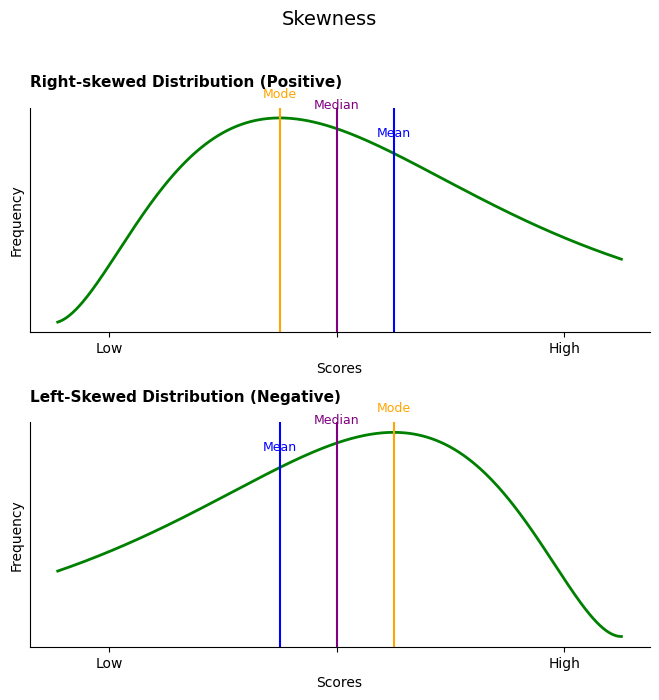

In [46]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.1, 10, 500) 

right_skew = (x**2) * np.exp(-0.5 * x) 

left_skew = ((10 - x)**2) * np.exp(-0.5 * (10 - x))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7)) 
fig.suptitle("Skewness", fontsize=14, y=1.02)
plt.subplots_adjust(hspace=0.4) 

def setup_ax(ax, title, color="green"):
    ax.plot(x, ax.curve, color=color, linewidth=2)
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold", pad=15)
    ax.set_xlabel("Scores")
    ax.set_ylabel("Frequency")
    ax.set_yticks([]) 
    ax.set_xticks([1, 5, 9], labels=["Low", "", "High"]) 
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)


ax1.curve = right_skew 
setup_ax(ax1, "Right-skewed Distribution (Positive)")

mode_d = 4.0 
median_d = 5.0
mean_d = 6.0 


ax1.axvline(mode_d, color="orange", linewidth=1.5)
ax1.text(mode_d, np.interp(mode_d, x, right_skew) * 1.1, "Mode", color="orange", ha="center", fontsize=9)

ax1.axvline(median_d, color="purple", linewidth=1.5)
ax1.text(median_d, np.interp(median_d, x, right_skew) * 1.1, "Median", color="purple", ha="center", fontsize=9)

ax1.axvline(mean_d, color="blue", linewidth=1.5)
ax1.text(mean_d, np.interp(mean_d, x, right_skew) * 1.1, "Mean", color="blue", ha="center", fontsize=9)


ax2.curve = left_skew
setup_ax(ax2, "Left-Skewed Distribution (Negative)")

mean_e = 4.0
median_e = 5.0
mode_e = 6.0

ax2.axvline(mean_e, color="blue", linewidth=1.5)
ax2.text(mean_e, np.interp(mean_e, x, left_skew) * 1.1, "Mean", color="blue", ha="center", fontsize=9)

ax2.axvline(median_e, color="purple", linewidth=1.5)
ax2.text(median_e, np.interp(median_e, x, left_skew) * 1.1, "Median", color="purple", ha="center", fontsize=9)

ax2.axvline(mode_e, color="orange", linewidth=1.5)
ax2.text(mode_e, np.interp(mode_e, x, left_skew) * 1.1, "Mode", color="orange", ha="center", fontsize=9)

plt.show()

#### Quality Control Analysis: Binomial Probability
##### This section analyzes manufacturing defects in a light bulb factory. Given a consistent 5% defect rate (p=0.05), we evaluate a random sample of 12 bulbs.

##### Objective: > To calculate the exact probability of identifying exactly 2 defective bulbs within the sample. We validate the theoretical probability formula using the scipy.stats.binom library to ensure production quality standards.

In [37]:
from scipy.stats import binom

n, p, x = 12, 0.05, 2
prob = binom.pmf(x, n, p)

print(f"A) P(X = 2) = {prob:.4f}")

A) P(X = 2) = 0.0988


##### Probability that at most 1 of the selected bulbs is defective

In [38]:
from scipy.stats import binom

n, p = 12, 0.05
prob = binom.cdf(1, n, p)  

print(f"B) P(X ≤ 1) = {prob:.4f}") 

B) P(X ≤ 1) = 0.8816


##### Probability that at least 3 of the selected bulbs are defective

In [39]:
from scipy.stats import binom

n, p = 12, 0.05

# CDF
prob1 = 1 - binom.cdf(2, n, p)

# SF (Survival Function)
prob2 = binom.sf(2, n, p)

print(f"C) P(X ≥ 3) = {prob1:.4f}")  
    

C) P(X ≥ 3) = 0.0196


##### Mean and standard deviation of the number of defective bulbs in a sample of this size

In [3]:
n, p = 12, 0.05
mean = n * p
sd = (n * p * (1 - p)) ** 0.5

mean_adj = 1.10 * mean + 5
sd_adj   = 1.10 * sd   + 5

print("D) Mean =", mean)
print("   Standard deviation =", sd)

D) Mean = 0.6000000000000001
   Standard deviation = 0.754983443527075


#### Sales Conversion Analysis: Predictive Modeling
##### In this scenario, we evaluate the efficiency of a telemarketing campaign by modeling sales outcomes as independent trials.

###### Operational Parameters:

###### Volume: 20 calls per hour.

###### Conversion Rate (Probability): 10% (0.1) success rate per call.

###### Objective:
###### We use the Binomial Distribution to assess performance volatility and calculate the probability of specific business outcomes:

###### Scenario A: The probability of achieving zero sales in a peak hour (Total conversion failure).

###### Scenario B: The probability of exceeding 2 sales per hour (Identifying high-performance windows).

###### This statistical approach allows the company to set realistic KPIs and understand the likelihood of variance in hourly sales targets.

In [22]:
from scipy.stats import binom

# data
n = 20   # calls
p = 0.1  # probability of sale

prob_no_sales = binom.pmf(0, n, p)  # probability of  0 sales in one hour


print(" A) Probability of no sales: (P(X=0)) =", (prob_no_sales))

 A) Probability of no sales: (P(X=0)) = 0.12157665459056918


##### Scenario B

In [23]:
from scipy.stats import binom

n = 20  
p = 0.1  

prob_more_than_2 = 1 - binom.cdf(2, n, p) 

print(" B) Probability of more than 2 sales: (P(X>2)) =", (prob_more_than_2))

 B) Probability of more than 2 sales: (P(X>2)) = 0.3230731948105341


#### Operational Traffic Modeling: Poisson Distribution

##### This analysis models the arrival rate of incoming calls to optimize staffing and resource allocation. We utilize the Poisson Distribution to estimate the probability of specific call volumes occurring within fixed time intervals

##### Operational Parameters:

##### Average Arrival Rate (λ): 4 calls per hour.

##### Objective:
##### We evaluate system readiness by calculating the probability of three distinct workload scenarios:

##### Scenario A: Receiving exactly 6 calls in one hour (Peak demand).

##### Scenario B: Receiving fewer than 3 calls in one hour (Low demand/Idle time).

##### Scenario C: Achieving a zero-call interval during a 30-minute period (Adjusting the interval rate to λ = 2).

##### This statistical modeling helps in determining the likelihood of system congestion and supports data-driven decisions for call center management.

In [ ]:
# data: lamb = 4 , x = 6 

In [31]:
from scipy.stats import poisson

lambda1, k = 4, 6
prob = poisson.pmf(k, lambda1)

print("A) Probability of exactly 6 calls (P(X=6)) =", prob)

A) Probability of exactly 6 calls (P(X=6)) = 0.10419563456702102


In [30]:
from scipy.stats import poisson

lamb = 4
prob = poisson.cdf(2, lamb)  

print("B) Probability of fewer than 3 calls (P(X<3)) =", prob)

B) Probability of fewer than 3 calls (P(X<3)) = 0.23810330555354436


In [39]:
from scipy.stats import poisson

l_adjusted = 2
prob = poisson.pmf(0, l_adjusted)

print("C) Probability of no calls in 30 minutes (P(X=0)) =", prob)

C) Probability of no calls in 30 minutes (P(X=0)) = 0.1353352832366127


#### Multi-Scale Workload Forecasting: Adjusted Poisson Modeling
##### This section demonstrates the flexibility of the Poisson Distribution in modeling events across varying time horizons. We analyze call center traffic by scaling the arrival rate to different operational windows.

##### Operational Parameters:

##### Base Rate: 15 calls per 10-minute interval.

##### Objective:
##### We calculate probabilities for specific organizational scenarios by adjusting the rate accordingly:

##### Scenario A (Short-term Scaling): Probability of receiving exactly 10 calls in a 5-minute window. This helps in managing immediate queue response.

##### Scenario B (Long-term Scaling): Probability of receiving fewer than 100 calls during a full 8-hour shift (9 AM - 5 PM).

##### This analysis is crucial for high-level capacity planning and determining if current staffing levels can handle the cumulative daily load without breaching service level agreements (SLAs).

In [41]:
from scipy.stats import poisson

l_adjusted, x = 7.5, 10
prob = poisson.pmf(x, l_adjusted)

print("A) Probability of exactly 10 calls (P(X=10)) =", prob)

A) Probability of exactly 10 calls (P(X=10)) = 0.08583037040867346


In [6]:
from scipy.stats import poisson

lambda_for_8_hours = 720
prob = poisson.cdf(99, lambda_for_8_hours)

if prob < 0.0001:
    prob = 0

print("B) Probability of fewer than 100 calls (P(X < 100)) =", prob)

B) Probability of fewer than 100 calls (P(X < 100)) = 0


#### Service Level Analysis: Exponential Distribution Modeling

##### This section evaluates operational efficiency by modeling the time required to complete customer service transactions. Using the Exponential Distribution, we can predict wait times and optimize staffing based on service speed.

##### Operational Parameters:

##### Average Service Time (1/λ): 5 minutes.

##### Rate Parameter (λ): 0.2 customers per minute.

##### Objective:

##### We model the probability of different service duration scenarios to better understand the customer journey:

##### Scenario A (Rapid Service): Probability of a customer being served in less than 3 minutes.

##### Scenario B (Service Delay): Probability of a customer waiting more than 10 minutes (identifying potential bottlenecks).

##### Scenario C (Standard Window): Probability of the service time falling between 4 and 8 minutes.

##### By applying the Cumulative Distribution Function (CDF), we can determine the likelihood of meeting specific service level targets and improve the overall banking hall flow.

In [21]:
from scipy.stats import expon

mean_time, x = 5, 3
prob = expon.cdf(x, scale=mean_time)

print(" A) Probability to be served in less than 3 minutes: (P(X < 3)) = ", prob)

 A) Probability to be served in less than 3 minutes: (P(X < 3)) =  0.4511883639059735
